In [39]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# Dataset
data = {
    "RAM": [4, 6, 8, 8, 12],
    "Storage": [64, 128, 128, 256, 256]
}

df = pd.DataFrame(data)

X = df[["RAM", "Storage"]]

# Polynomial Features (Degree = 2)
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

print("Polynomial Feature Names:")
print(poly.get_feature_names_out())

print("\nPolynomial Feature Matrix:")
print(X_poly)

Polynomial Feature Names:
['1' 'RAM' 'Storage' 'RAM^2' 'RAM Storage' 'Storage^2']

Polynomial Feature Matrix:
[[1.0000e+00 4.0000e+00 6.4000e+01 1.6000e+01 2.5600e+02 4.0960e+03]
 [1.0000e+00 6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]
 [1.0000e+00 8.0000e+00 1.2800e+02 6.4000e+01 1.0240e+03 1.6384e+04]
 [1.0000e+00 8.0000e+00 2.5600e+02 6.4000e+01 2.0480e+03 6.5536e+04]
 [1.0000e+00 1.2000e+01 2.5600e+02 1.4400e+02 3.0720e+03 6.5536e+04]]


In [40]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# Dataset
data = {
    "RAM": [4, 6, 8, 8, 12],
    "Storage": [64, 128, 128, 256, 256]
}

df = pd.DataFrame(data)

X = df[["RAM", "Storage"]]

# Polynomial Features (Degree = 2)
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

print("Polynomial Feature Names:")
print(poly.get_feature_names_out())

print("\nPolynomial Feature Matrix:")
print(X_poly)

Polynomial Feature Names:
['1' 'RAM' 'Storage' 'RAM^2' 'RAM Storage' 'Storage^2']

Polynomial Feature Matrix:
[[1.0000e+00 4.0000e+00 6.4000e+01 1.6000e+01 2.5600e+02 4.0960e+03]
 [1.0000e+00 6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]
 [1.0000e+00 8.0000e+00 1.2800e+02 6.4000e+01 1.0240e+03 1.6384e+04]
 [1.0000e+00 8.0000e+00 2.5600e+02 6.4000e+01 2.0480e+03 6.5536e+04]
 [1.0000e+00 1.2000e+01 2.5600e+02 1.4400e+02 3.0720e+03 6.5536e+04]]


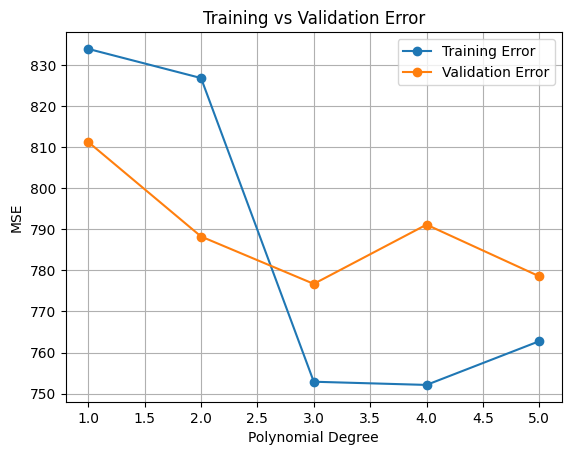

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Synthetic Dataset
np.random.seed(42)

followers = np.linspace(100,1000,80)

posts = 0.000001*(followers**2) + np.random.normal(0,30,80)

X = followers.reshape(-1,1)

y = posts

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

train_error=[]

test_error=[]

for degree in range(1,6):

    poly = PolynomialFeatures(degree)

    Xtr = poly.fit_transform(X_train)

    Xte = poly.transform(X_test)

    model = LinearRegression()

    model.fit(Xtr,y_train)

    train_pred = model.predict(Xtr)

    test_pred = model.predict(Xte)

    train_error.append(
        mean_squared_error(y_train,train_pred)
    )

    test_error.append(
        mean_squared_error(y_test,test_pred)
    )

plt.plot(range(1,6),train_error,marker="o",label="Training Error")

plt.plot(range(1,6),test_error,marker="o",label="Validation Error")

plt.xlabel("Polynomial Degree")

plt.ylabel("MSE")

plt.title("Training vs Validation Error")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression,Ridge

from sklearn.metrics import mean_squared_error

# Sample Dataset

price = np.array([100,200,300,400,500,600,700,800])

rating = np.array([10,20,35,55,80,110,150,190])

X = price.reshape(-1,1)

y = rating

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

poly = PolynomialFeatures(degree=3)

Xtr = poly.fit_transform(X_train)

Xte = poly.transform(X_test)

# Polynomial Regression

linear = LinearRegression()

linear.fit(Xtr,y_train)

pred1 = linear.predict(Xte)

# Ridge Regression

ridge = Ridge(alpha=1.0)

ridge.fit(Xtr,y_train)

pred2 = ridge.predict(Xte)

print("Polynomial Regression Test MSE")

print(mean_squared_error(y_test,pred1))

print()

print("Ridge Regression Test MSE")

print(mean_squared_error(y_test,pred2))

Polynomial Regression Test MSE
63.04904332820636

Ridge Regression Test MSE
61.622256447849


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.84708e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


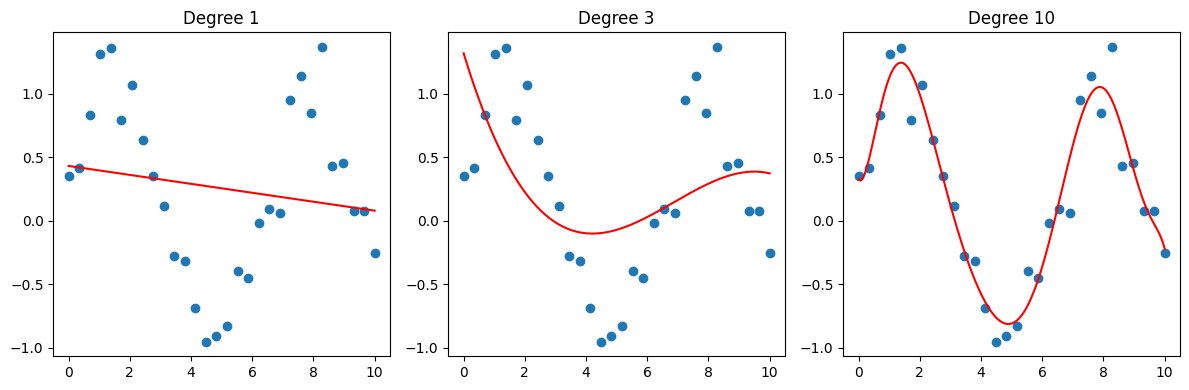

In [43]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

# Dataset

np.random.seed(0)

X = np.linspace(0,10,30)

y = np.sin(X)+np.random.normal(0,0.2,30)

X = X.reshape(-1,1)

plt.figure(figsize=(12,4))

degrees=[1,3,10]

for i,degree in enumerate(degrees):

    poly = PolynomialFeatures(degree)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_poly,y)

    X_new=np.linspace(0,10,200).reshape(-1,1)

    y_pred=model.predict(poly.transform(X_new))

    plt.subplot(1,3,i+1)

    plt.scatter(X,y)

    plt.plot(X_new,y_pred,color="red")

    plt.title(f"Degree {degree}")

plt.tight_layout()

plt.show()